# Analysis of Old Data
- data generated in December 2024, data received Feb 2025
- looking as comparison for QC

In [1]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# snRNAseq
import anndata as ad
import scanpy as sc


# Load and merge data

In [ ]:
# specify data paths
home_path = "/Volumes/S2D1/"

samples = ["MM1", "MM2", "ST1", "ST2"]

in_dir = home_path+"Emily/transcriptomics/snRNAseq/25Feb_snRNA_OMC/Banerjee_EI01/count/"

file_paths = [in_dir+"Banerjee_EI01_"+s+"/outs/filtered_feature_bc_matrix.h5" for s in samples]
file_paths


In [ ]:
adatas_list = []
for i in range(len(samples)):
    s= samples[i]
    fp = file_paths[i]
    adata = sc.read_10x_h5(fp)
    adatas_list.append(adata)

adatas_list[0]


In [ ]:
for i in range(len(samples)):
    df = adatas_list[i]
    s = samples[i]
    reps = df.n_obs
    df.obs["sample"] = np.repeat(s, reps)
    if i in [1,2]:
        df.obs["species"] = np.repeat("Mmus", reps)
    else:
        df.obs["species"] = np.repeat("Steg", reps)

    # reset index for merging
    df.var = df.var.reset_index(names="gene_names").set_index("gene_ids")


adatas_list[0]

In [ ]:
# merge lab mouse data
mm1 = adatas_list[0]
mm2 = adatas_list[1]
mm_adata = ad.concat([mm1,mm2], join="outer", merge="same")
mm_adata.var = mm_adata.var.reset_index().set_index("gene_names")

# merge singing mouse data
st1 = adatas_list[2]
st2 = adatas_list[3]
st_adata = ad.concat([st1,st2], join="outer", merge="same")
st_adata.var = st_adata.var.reset_index().set_index("gene_names")

In [ ]:
# save objects
mm_adata.write("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_MM.h5ad")
st_adata.write("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_ST.h5ad")



# Quality Control

In [3]:
mm = sc.read_h5ad("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_MM.h5ad")
st = sc.read_h5ad("/Users/eisko/data/Banerjee_EI01/Banerjee_EI01_ST.h5ad")

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
mm.var.index.str.startswith("mt")

array([False, False, False, ..., False, False, False], shape=(32285,))

In [8]:
# 13 mitochondrial genes
mito_idx = mm.var.index.str.startswith("mt")
mito = mm.var.index[mito_idx]
print(mito)
print(f"{len(mito)} mito genes")

# ribo genes
ribo_idx = mm.var.index.str.startswith(("Rps", "Rpl"))
ribo = mm.var.index[ribo_idx]
print("\n",ribo)
print(f"{len(ribo)} ribo genes")

# Hemoglobin genes
hemo_idx = mm.var.index.str.contains("Hb[^spe]")
hemo = mm.var.index[hemo_idx]
print("\n",hemo)
print(f"{len(hemo)} hemo genes")

Index(['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb'],
      dtype='object', name='gene_names')
13 mito genes

 Index(['Rpl7', 'Rpl31', 'Rpl37a', 'Rps6kc1', 'Rpl7a', 'Rpl12', 'Rpl35',
       'Rps21', 'Rpl22l1', 'Rps3a1',
       ...
       'Rpl17', 'Rps6kb2', 'Rps6ka4', 'Rpl9-ps6', 'Rpl39', 'Rpl10', 'Rps4x',
       'Rps6ka6', 'Rpl36a', 'Rps6ka3'],
      dtype='object', name='gene_names', length=101)
101 ribo genes

 Index(['Hbb-bt', 'Hbb-bs', 'Hbb-bh2', 'Hbb-bh1', 'Hbb-y', 'Hba-x', 'Hba-a1',
       'Hbq1b', 'Hba-a2', 'Hbq1a'],
      dtype='object', name='gene_names')
10 hemo genes


In [9]:
# Mitochondrial genes
mm.var["mt"] = mm.var_names.str.startswith("mt-")

# Ribosomal genes
mm.var["ribo"] = mm.var_names.str.startswith(("Rps", "Rpl"))

# hemoglobin genes
mm.var["hb"] = mm.var_names.str.contains("Hb[^spe]")

In [10]:
sc.pp.calculate_qc_metrics(mm, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mm.var_keys

<bound method AnnData.var_keys of AnnData object with n_obs × n_vars = 49479 × 32285
    obs: 'sample', 'species', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'>

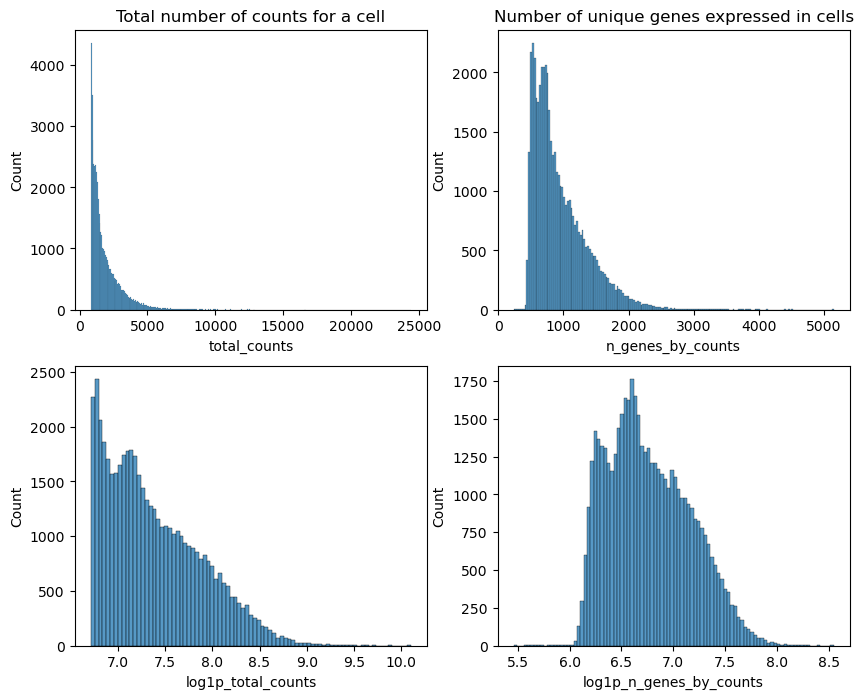

In [11]:
fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(mm.obs["total_counts"], ax=axs[0,0])
axs[0,0].set_title("Total number of counts for a cell")

sns.histplot(mm.obs["n_genes_by_counts"], ax=axs[0,1])
axs[0,1].set_title("Number of unique genes expressed in cells")

sns.histplot(mm.obs["log1p_total_counts"], ax=axs[1,0])

sns.histplot(mm.obs["log1p_n_genes_by_counts"], ax=axs[1,1])

plt.show()

In [15]:
mm.var_names_make_unique()

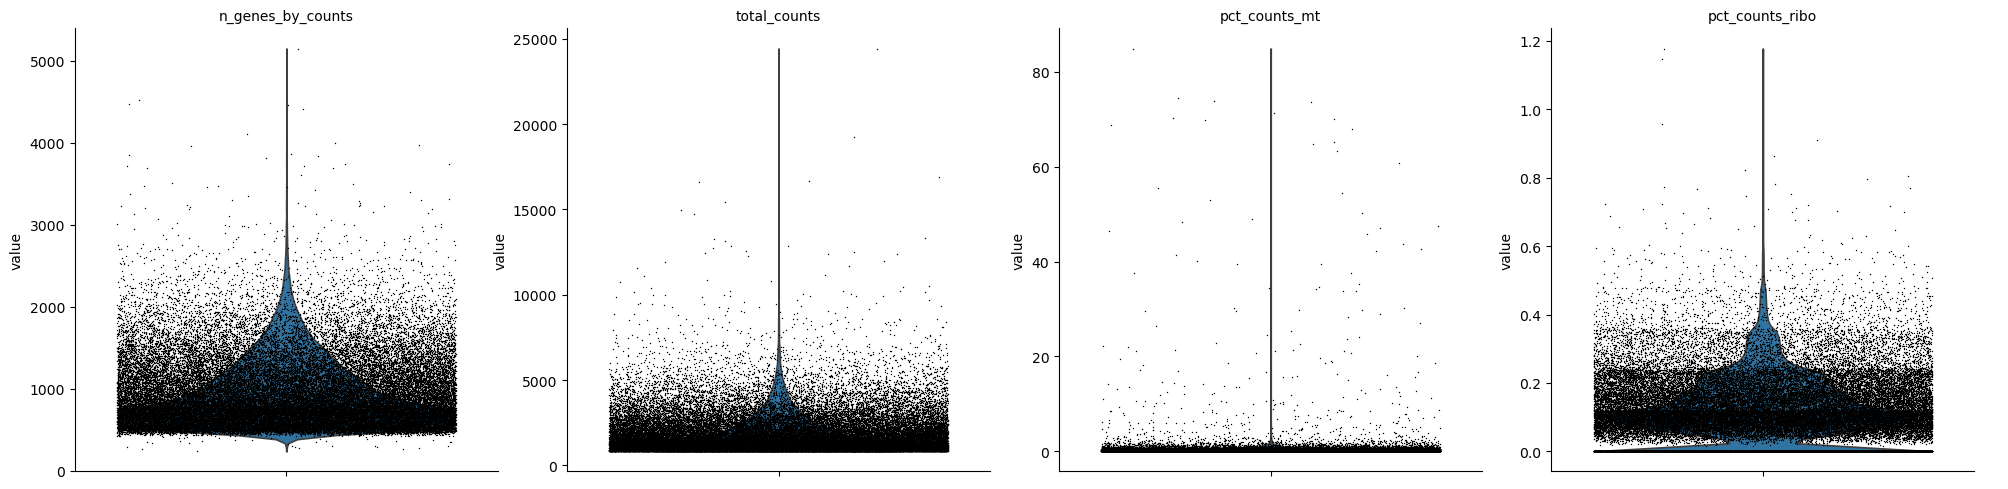

In [16]:
# scanpy, plotting, violin
sc.pl.violin(
    mm,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_37859/798576039.py:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


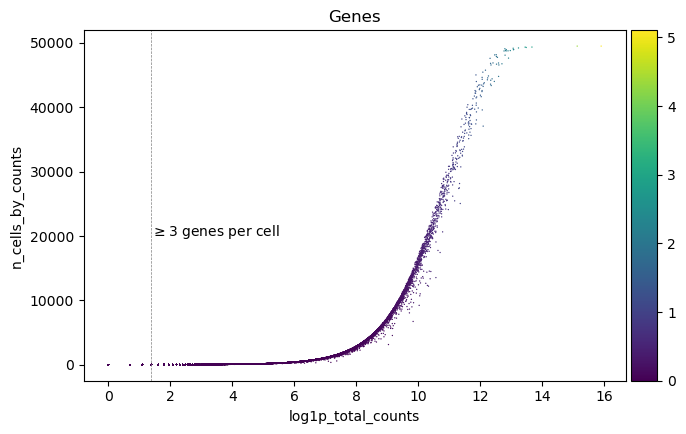

In [17]:
axes = sc.pl.scatter(mm, "log1p_total_counts", "n_cells_by_counts", color="log1p_mean_counts", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(np.log1p(3), c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.set_title("Genes")
axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")
plt.show()


<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_37859/63739230.py:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(2000, 6000, "$\geq$2000 counts per cell")


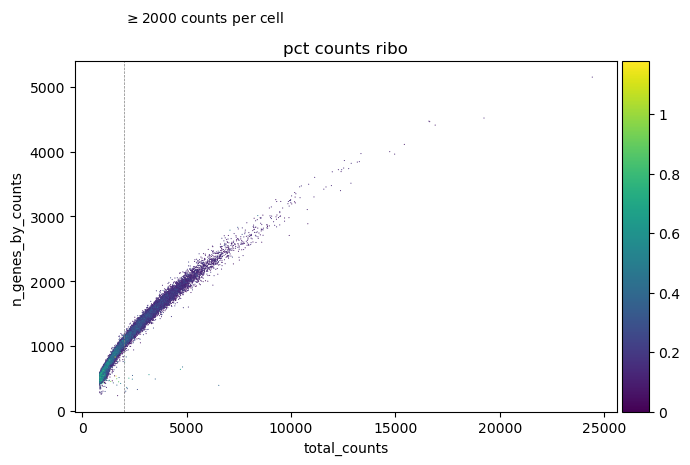

In [18]:
axes = sc.pl.scatter(mm, "total_counts", "n_genes_by_counts", color="pct_counts_ribo", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.text(2000, 6000, "$\geq$2000 counts per cell")
plt.show()



In [20]:
# number of cells w/ total gene counts > 2000
cells_pass = sum(mm.obs["total_counts"]>2000)
print(f"{cells_pass}/{mm.n_obs} cells pass")

# number of genes w/ total cell counts > 3
genes_pass = sum(mm.var["total_counts"]>3)
print(f"{genes_pass}/{mm.n_vars} genes pass")

15293/49479 cells pass
21652/32285 genes pass


# Doublet detection

In [21]:
mm.obs_names_make_unique()

sc.pp.scrublet(mm)

print(f"Number of predicted doublets: {sum(mm.obs["predicted_doublet"])}")

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Number of predicted doublets: 0
